# Philippine Food Price Analysis (EDA)

This notebook explores food price data in the Philippines using Python.

## Objectives
- Understand dataset structure
- Analyze price trends over time
- Compare prices across regions and commodities
- Identify patterns and anomalies

## Data Loading

In this section, the cleaned dataset is loaded into a pandas DataFrame. The `parse_dates` parameter ensures that the `date` column is interpreted as a datetime object, which is important for time-based analysis.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_food_prices.csv", parse_dates=["date"])

df.head()

,date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice
0,2000-01-15,National Capital region,Metropolitan Manila,Metro Manila,14.604167,120.982222,cereals and tubers,Maize flour (yellow),KG,actual,Retail,PHP,15.00,0.3717
1,2000-01-15,Region XII,South Cotabato,Koronadal,6.503056,124.846944,cereals and tubers,"Rice (regular, milled)",KG,actual,Retail,PHP,16.50,0.4089
2,2000-01-15,Region XII,South Cotabato,Koronadal,6.503056,124.846944,cereals and tubers,"Rice (milled, superior)",KG,actual,Wholesale,PHP,16.00,0.3965
3,2000-01-15,Region XII,South Cotabato,Koronadal,6.503056,124.846944,cereals and tubers,"Rice (milled, superior)",KG,actual,Retail,PHP,18.00,0.4461
4,2000-01-15,Region XI,Davao del Sur,Davao City,7.180000,125.440000,cereals and tubers,"Rice (regular, milled)",KG,actual,Wholesale,PHP,15.35,0.3804


## Dataset Overview

This section provides a general overview of the dataset, including its dimensions, column names, data types, and summary statistics. This helps in understanding the structure and contents of the data before deeper analysis.

In [10]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 121512 entries, 0 to 121511
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       121512 non-null  datetime64[us]
 1   admin1     121512 non-null  str           
 2   admin2     121512 non-null  str           
 3   market     121512 non-null  str           
 4   latitude   121512 non-null  float64       
 5   longitude  121512 non-null  float64       
 6   category   121512 non-null  str           
 7   commodity  121512 non-null  str           
 8   unit       121512 non-null  str           
 9   priceflag  121512 non-null  str           
 10  pricetype  121512 non-null  str           
 11  currency   121512 non-null  str           
 12  price      121512 non-null  float64       
 13  usdprice   121512 non-null  float64       
dtypes: datetime64[us](1), float64(4), str(9)
memory usage: 22.7 MB


,date,latitude,longitude,price,usdprice
count,121512,121512.000000,121512.000000,121512.000000,121512.000000
mean,2020-06-20 04:05:15.702152,11.677894,122.896054,113.832759,2.214077
min,2000-01-15 00:00:00,5.029099,118.735278,3.480000,0.070000
25%,2020-08-15 00:00:00,8.482192,121.086142,40.630000,0.803700
50%,2021-06-15 00:00:00,11.560250,122.755280,76.130000,1.481700
75%,2022-09-15 00:00:00,14.608900,124.651647,152.500000,2.995300
max,2023-11-15 00:00:00,18.194082,126.207645,1166.000000,21.062900
std,NaN,3.592040,1.909137,111.108869,2.131123


## Missing Values Analysis

This step checks for missing values in each column. Identifying missing data is essential for evaluating data quality and determining whether further cleaning is needed.

In [11]:
df.isnull().sum()

date         0
admin1       0
admin2       0
market       0
latitude     0
longitude    0
category     0
commodity    0
unit         0
priceflag    0
pricetype    0
currency     0
price        0
usdprice     0
dtype: int64

## Unique Categories

This section examines the number of unique commodities, markets, and regions in the dataset. This helps show the scope and diversity of the available records.

In [12]:
print("Unique commodities:", df["commodity"].nunique())
print("Unique markets:", df["market"].nunique())
print("Unique regions:", df["admin1"].nunique())

Unique commodities: 73
Unique markets: 108
Unique regions: 17


## Most Common Commodities

This part identifies the commodities that appear most frequently in the dataset. It provides an idea of which food items are most commonly monitored across markets.

In [13]:
df["commodity"].value_counts().head(10)

commodity
Rice (regular, milled)    4969
Cabbage                   4459
Eggplants                 3528
Rice (well milled)        3518
Fish (milkfish)           3389
Bitter melon              3375
Fish (roundscad)          3272
Rice (special)            3235
Coconut                   3186
Beans (mung)              3171
Name: count, dtype: int64

## Price Distribution

This histogram shows how food prices are distributed across all records. It helps reveal the concentration of prices, as well as the presence of possible outliers or highly priced commodities.

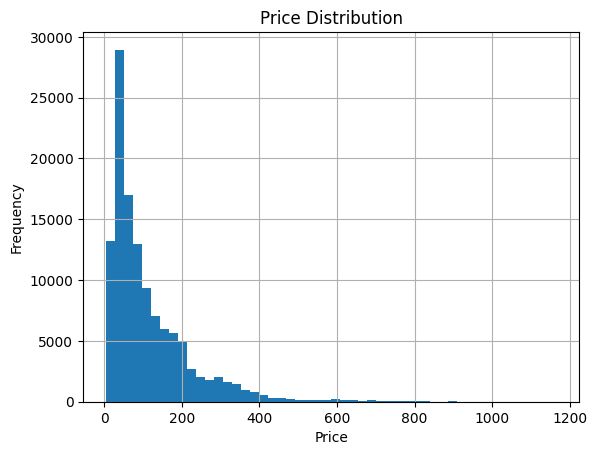

In [14]:
plt.figure()
df["price"].hist(bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Price Volatility

This section measures price volatility using standard deviation. Commodities with high volatility experience more price fluctuations, which may indicate supply instability or seasonal effects.

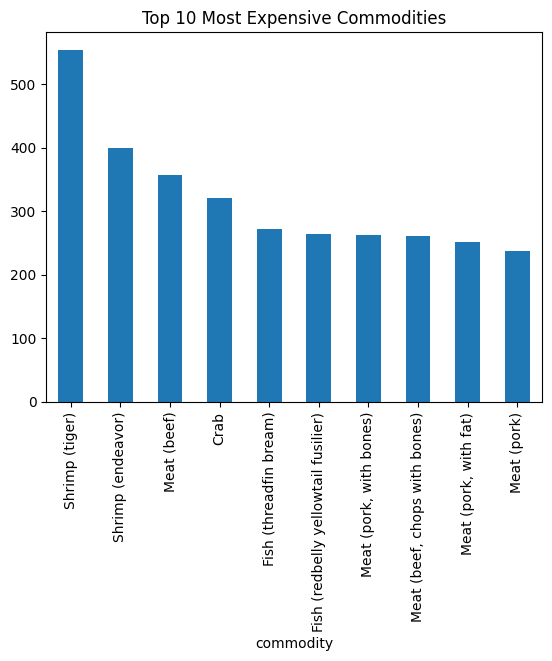

In [15]:
avg_price = df.groupby("commodity")["price"].mean().sort_values(ascending=False)

avg_price.head(10)
avg_price.head(10).plot(kind="bar")
plt.title("Top 10 Most Expensive Commodities")
plt.show()

region_avg = df.groupby("admin1")["price"].mean().sort_values(ascending=False)

## Average Price by Region

This analysis compares the average food prices across regions. It helps identify geographic differences in food costs and shows which regions tend to have higher average prices.

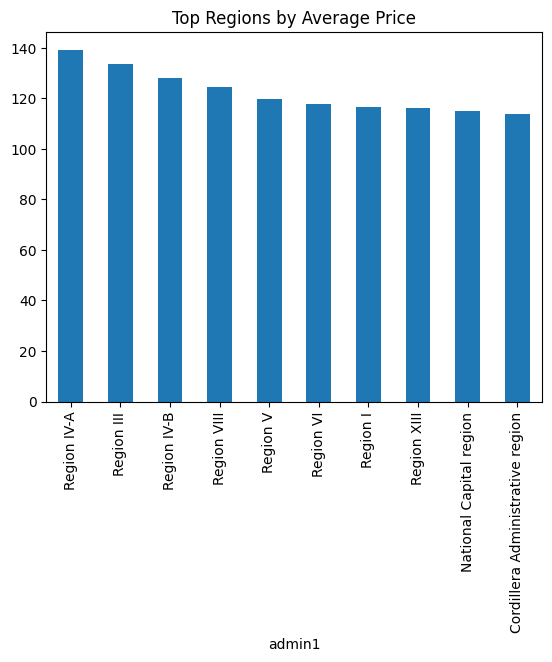

In [16]:
region_avg.head(10)

region_avg.head(10).plot(kind="bar")
plt.title("Top Regions by Average Price")
plt.show()

## Overall Price Trend Over Time

This section examines how average food prices change over time. It helps identify long-term trends, seasonal patterns, or price spikes.

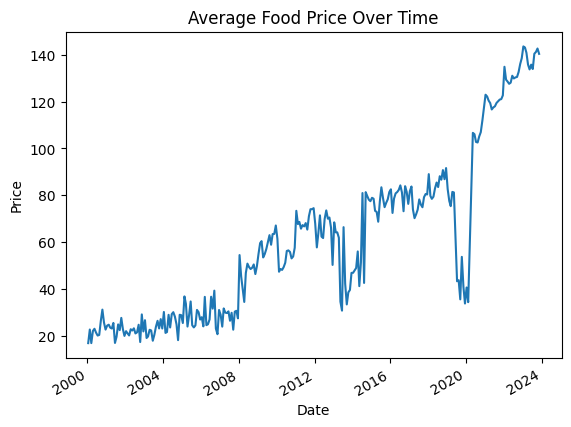

In [17]:
trend = df.groupby("date")["price"].mean()

plt.figure()
trend.plot()
plt.title("Average Food Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Rice Price Trend

Rice is a staple food in the Philippines. This section focuses specifically on rice to analyze how its price changes over time.

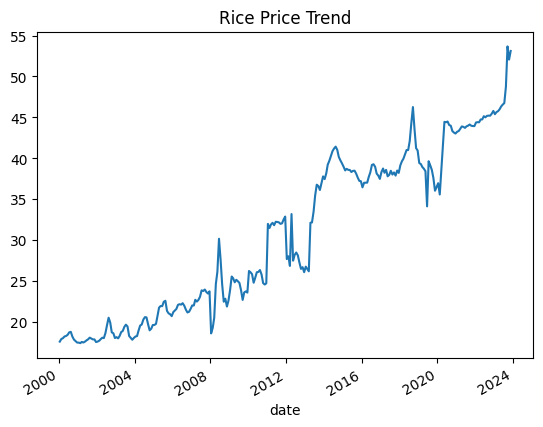

In [18]:
rice = df[df["commodity"].str.contains("Rice", case=False)]

rice_trend = rice.groupby("date")["price"].mean()

plt.figure()
rice_trend.plot()
plt.title("Rice Price Trend")
plt.show()

## Monthly Price Trend

To better understand trends, prices are aggregated monthly. This smooths daily fluctuations and highlights broader patterns.

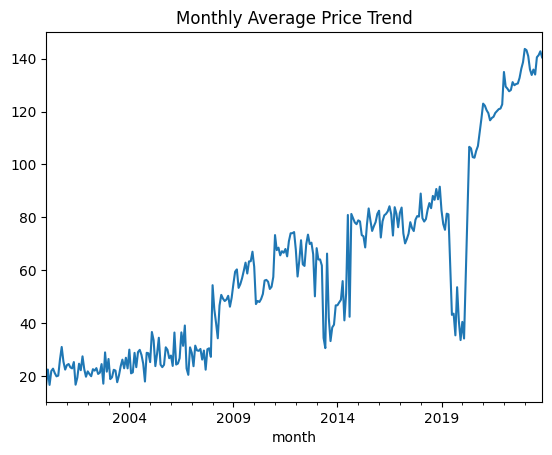

In [19]:
df["month"] = df["date"].dt.to_period("M")

monthly = df.groupby("month")["price"].mean()

monthly.plot()
plt.title("Monthly Average Price Trend")
plt.show()

## Price Volatility

This section measures price volatility using standard deviation. Commodities with high volatility experience more price fluctuations, which may indicate supply instability or seasonal effects.

In [20]:
volatility = df.groupby("commodity")["price"].std().sort_values(ascending=False)

volatility.head(10)

commodity
Shrimp (tiger)                         157.269161
Shrimp (endeavor)                      104.760910
Fish (slipmouth)                        88.223786
Crab                                    82.844880
Meat (pork)                             75.325285
Meat (beef, chops with bones)           69.711830
Onions (red)                            69.083579
Fish (redbelly yellowtail fusilier)     65.476397
Fish (threadfin bream)                  64.977995
Garlic (small)                          63.686451
Name: price, dtype: float64

## Key Insights

- Rice shows consistent price trends over time
- Some regions have significantly higher average prices
- Certain commodities exhibit high volatility
- Price spikes may indicate supply issues or seasonal changes